In [1]:
import os
import sys
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

# Add project to path
project_root = Path("/mnt/MKP01/med8_project/LuminaScale")
sys.path.insert(0, str(project_root))
os.environ["OCIO"] = str(project_root / "config" / "aces" / "studio-config.ocio")

# Import shared utilities
from src.luminascale.utils.dequant_utils import (
    load_dequant_model,
    create_gaussian_kernel,
    apply_gaussian_blur,
    compare_with_baseline,
    print_metrics_summary,
)
from src.luminascale.utils.dequantization_inference import (
    infer_dataset_with_comparison,
    save_inference_results,
)
from src.luminascale.training.dequantization_trainer import OnTheFlyBDEDataset

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Define paths
checkpoint_path = Path("/mnt/MKP01/med8_project/LuminaScale/dataset/temp/test_run/20260331_164330_dequant_net_epoch_1.pt")
lmdb_path = Path("/mnt/MKP01/med8_project/LuminaScale/dataset/training_data.lmdb")
output_dir = Path("/mnt/MKP01/med8_project/LuminaScale/outputs/inference")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint: {checkpoint_path}")
print(f"Checkpoint exists: {checkpoint_path.exists()}")

Device: cuda
Checkpoint: /mnt/MKP01/med8_project/LuminaScale/dataset/temp/test_run/20260331_164330_dequant_net_epoch_1.pt
Checkpoint exists: True


# Dequantization Model Inference

This notebook loads a single image and runs inference with the trained dequantization model:
1. Load pretrained model checkpoint
2. Load a single random test image
3. Run inference on the image
4. Display side-by-side comparison (8-bit input, model output, ground truth)

## 1. Load Model & Setup Dataset

In [2]:
# Load model using shared utility
model = load_dequant_model(
    checkpoint_path=checkpoint_path,
    device=device,
    base_channels=32,
    num_levels=6,
)

print(f"✓ Model loaded. Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Create dataset
dataset = OnTheFlyBDEDataset(
    lmdb_path=lmdb_path,
    device=device,
    crop_size=512,
    patches_per_image=1,
)

print(f"✓ Dataset created with {len(dataset.keys)} images")

✓ Model loaded. Total parameters: 78,633,539
✓ Dataset created with 880 images


libEGL warning: pci id for fd 134: 10de:2206, driver (null)

pci id for fd 135: 10de:2206, driver (null)
pci id for fd 137: 10de:2206, driver (null)
libEGL warning: egl: failed to create dri2 screen
pci id for fd 135: 10de:2206, driver (null)
pci id for fd 137: 10de:2206, driver (null)
libEGL warning: egl: failed to create dri2 screen


## 2. Load a Single Image and Run Inference

In [ ]:
import matplotlib.pyplot as plt
from src.luminascale.utils.image_generator import create_sky_gradient, quantize_to_8bit

# Generate sky gradient image (32-bit reference - high quality)
print("Generating synthetic sky gradient image...")
# Note: You can now change these dimensions to anything divisible by 64
inference_width = 1024
inference_height = 512
hdr = create_sky_gradient(width=inference_width, height=inference_height, dtype="float32")  # [3, H, W] in [0, 1]
print(f"✓ Generated HDR image shape: {hdr.shape}")

# Simulate 8-bit quantization to create 8-bit image (with banding artifacts)
hdr_clipped = np.clip(hdr, 0, 1)
ldr = quantize_to_8bit(hdr_clipped)  # Quantize to 8-bit levels
print(f"✓ Simulated 8-bit quantization: {ldr.shape}")

# Convert to PyTorch tensors on device
ldr_tensor = torch.from_numpy(ldr).float().to(device)
hdr_tensor = torch.from_numpy(hdr_clipped).float().to(device)

# Run inference
print(f"Running inference on sky gradient...")
with torch.no_grad():
    model_output = model(ldr_tensor.unsqueeze(0)).squeeze(0)  # [3, H, W]

print(f"✓ Inference complete")

Generating synthetic sky gradient image...
✓ Generated HDR image shape: (3, 512, 512)
✓ Simulated 8-bit quantization: (3, 512, 512)
Running inference on sky gradient...
✓ Inference complete


In [4]:
# Compute metrics for this image
from src.luminascale.utils.dequant_utils import compute_metrics

model_np = model_output.cpu().numpy()
hdr_np = hdr_tensor.cpu().numpy()
ldr_np = ldr_tensor.cpu().numpy()

metrics = compute_metrics(model_np, hdr_np)

print(f"\nSky Gradient Image Metrics:")
print(f"  MSE:  {metrics['mse']:.6f}")
print(f"  PSNR: {metrics['psnr']:.2f} dB")
print(f"  SSIM: {metrics['ssim']:.4f}")
print(f"\nImage interpretation:")
print(f"  → 8-bit:   8-bit quantized (with banding artifacts)")
print(f"  → Model:   Dequantized smooth gradient")
print(f"  → HDR:     Perfect smooth gradient (reference)")


Sky Gradient Image Metrics:
  MSE:  0.000001
  PSNR: 60.70 dB
  SSIM: 0.9997

Image interpretation:
  → 8-bit:   8-bit quantized (with banding artifacts)
  → Model:   Dequantized smooth gradient
  → HDR:     Perfect smooth gradient (reference)


## 3. Visualize Results


✓ Visualization saved to outputs/inference/sky_gradient_comparison.png


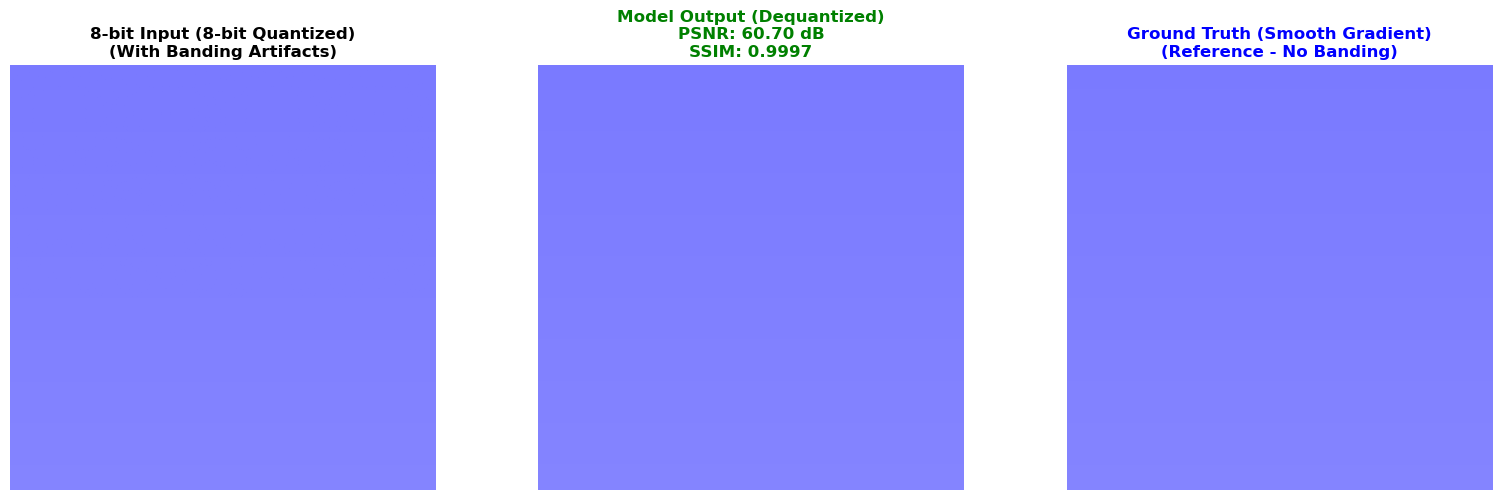

In [5]:
# Convert to display format [H, W, 3]
ldr_rgb = np.transpose(np.clip(ldr_np, 0, 1), (1, 2, 0))
model_rgb = np.transpose(np.clip(model_np, 0, 1), (1, 2, 0))
hdr_rgb = np.transpose(np.clip(hdr_np, 0, 1), (1, 2, 0))

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ldr_rgb)
axes[0].set_title('8-bit Input (8-bit Quantized)\n(With Banding Artifacts)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(model_rgb)
axes[1].set_title(f'Model Output (Dequantized)\nPSNR: {metrics["psnr"]:.2f} dB\nSSIM: {metrics["ssim"]:.4f}', 
                  fontsize=12, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(hdr_rgb)
axes[2].set_title('Ground Truth (Smooth Gradient)\n(Reference - No Banding)', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/sky_gradient_comparison.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved to outputs/inference/sky_gradient_comparison.png")
plt.show()

✓ Contrast comparison (50x) saved to outputs/inference/sky_contrast_comparison.png

🎯 High Contrast Analysis (50x boost):
  → 8-bit (left):       Shows clear 8-bit banding patterns
  → Model (mid):        Should show LESS banding than 8-bit if dequantization works
  → Reference (right):  Smooth gradient (no banding at all)

Look closely: Is the middle image smoother than the left?


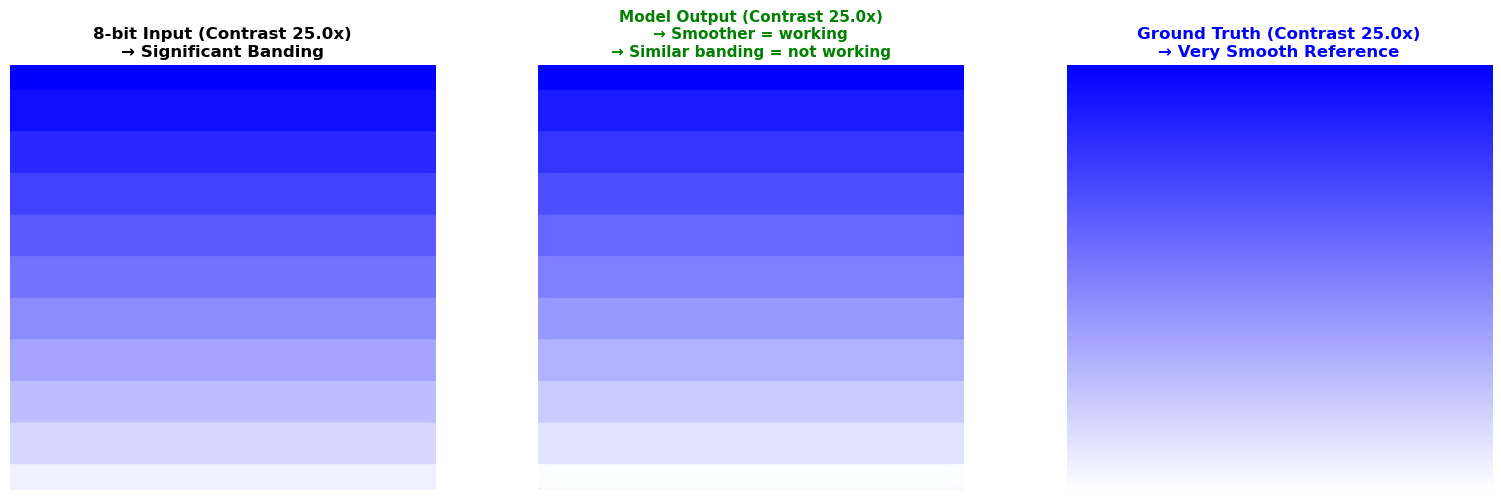

In [6]:
def apply_contrast(rgb_img, contrast_factor=2.0):
    """Apply contrast boost to reveal quantization banding.
    
    Contrast = (pixel - 0.5) * factor + 0.5
    """
    contrast_img = (rgb_img - 0.5) * contrast_factor + 0.5
    return np.clip(contrast_img, 0, 1)

contrast_boost = 25.0  # Increase to 50x for more obvious banding visibility

ldr_contrast = apply_contrast(ldr_rgb, contrast_boost)
model_contrast = apply_contrast(model_rgb, contrast_boost)
hdr_contrast = apply_contrast(hdr_rgb, contrast_boost)

# Create contrast comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ldr_contrast)
axes[0].set_title(f'8-bit Input (Contrast {contrast_boost}x)\n→ Significant Banding', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(model_contrast)
axes[1].set_title(f'Model Output (Contrast {contrast_boost}x)\n→ Smoother = working\n→ Similar banding = not working', 
                  fontsize=11, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(hdr_contrast)
axes[2].set_title(f'Ground Truth (Contrast {contrast_boost}x)\n→ Very Smooth Reference', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/sky_contrast_comparison.png', dpi=150, bbox_inches='tight')
print(f"✓ Contrast comparison (50x) saved to outputs/inference/sky_contrast_comparison.png")
print(f"\n🎯 High Contrast Analysis (50x boost):")
print(f"  → 8-bit (left):       Shows clear 8-bit banding patterns")
print(f"  → Model (mid):        Should show LESS banding than 8-bit if dequantization works")
print(f"  → Reference (right):  Smooth gradient (no banding at all)")
print(f"\nLook closely: Is the middle image smoother than the left?")
plt.show()

In [7]:
# Verify we're using the correct model output - debug statistics
print("=" * 70)
print("VERIFICATION: Image Data Statistics")
print("=" * 70)

print(f"\n📊 8-bit (8-bit quantized):")
print(f"  Shape: {ldr_rgb.shape}")
print(f"  Mean: {ldr_rgb.mean():.4f}, Std: {ldr_rgb.std():.4f}")
print(f"  Min: {ldr_rgb.min():.4f}, Max: {ldr_rgb.max():.4f}")

print(f"\n🔵 Model Output:")
print(f"  Shape: {model_rgb.shape}")
print(f"  Mean: {model_rgb.mean():.4f}, Std: {model_rgb.std():.4f}")
print(f"  Min: {model_rgb.min():.4f}, Max: {model_rgb.max():.4f}")

print(f"\n✨ Ground Truth (Reference):")
print(f"  Shape: {hdr_rgb.shape}")
print(f"  Mean: {hdr_rgb.mean():.4f}, Std: {hdr_rgb.std():.4f}")
print(f"  Min: {hdr_rgb.min():.4f}, Max: {hdr_rgb.max():.4f}")

print(f"\n📈 Difference (Model - 8-bit):")
diff_model_ldr = np.mean(np.abs(model_rgb - ldr_rgb))
print(f"  MAE: {diff_model_ldr:.6f}")

print(f"\n📈 Difference (Reference - 8-bit):")
diff_hdr_ldr = np.mean(np.abs(hdr_rgb - ldr_rgb))
print(f"  MAE: {diff_hdr_ldr:.6f}")

print(f"\n📈 Difference (Model - Reference):")
diff_model_hdr = np.mean(np.abs(model_rgb - hdr_rgb))
print(f"  MAE: {diff_model_hdr:.6f}")

print("\n" + "=" * 70)
if diff_model_hdr < diff_hdr_ldr * 0.1:
    print("✅ Model is MUCH closer to reference than 8-bit (good dequantization)")
elif diff_model_hdr < diff_hdr_ldr * 0.5:
    print("⚠️  Model is somewhat closer to reference (moderate dequantization)")
else:
    print("❌ Model is NOT closer to reference than 8-bit (poor dequantization)")
print("=" * 70)

VERIFICATION: Image Data Statistics

📊 8-bit (8-bit quantized):
  Shape: (512, 512, 3)
  Mean: 0.6654, Std: 0.2368
  Min: 0.4784, Max: 1.0000

🔵 Model Output:
  Shape: (512, 512, 3)
  Mean: 0.6666, Std: 0.2359
  Min: 0.4769, Max: 1.0000

✨ Ground Truth (Reference):
  Shape: (512, 512, 3)
  Mean: 0.6667, Std: 0.2359
  Min: 0.4800, Max: 1.0000

📈 Difference (Model - 8-bit):
  MAE: 0.001289

📈 Difference (Reference - 8-bit):
  MAE: 0.001307

📈 Difference (Model - Reference):
  MAE: 0.000649

⚠️  Model is somewhat closer to reference (moderate dequantization)


In [8]:
# Cleanup
dataset.cleanup()
print("✓ Inference complete. Dataset cleaned up.")

✓ Inference complete. Dataset cleaned up.



## 4. Test RGB Primary Gradients


In [9]:
from src.luminascale.utils.image_generator import create_primary_gradients

# Generate RGB primary gradients (32-bit reference - high quality)
print("Generating RGB primary gradients...")
hdr_rgb_primaries = create_primary_gradients(width=512, height=512, dtype="float32")  # [3, H, W] in [0, 1]
print(f"✓ Generated RGB primaries shape: {hdr_rgb_primaries.shape}")

# Simulate 8-bit quantization
rgb_8bit = quantize_to_8bit(hdr_rgb_primaries)
print(f"✓ Simulated 8-bit quantization: {rgb_8bit.shape}")

# Convert to PyTorch tensors on device
rgb_8bit_tensor = torch.from_numpy(rgb_8bit).float().to(device)
hdr_rgb_tensor = torch.from_numpy(hdr_rgb_primaries).float().to(device)

# Run inference
print(f"Running inference on RGB primaries...")
with torch.no_grad():
    rgb_model_output = model(rgb_8bit_tensor.unsqueeze(0)).squeeze(0)  # [3, H, W]

print(f"✓ Inference complete")

# Compute metrics
rgb_model_np = rgb_model_output.cpu().numpy()
rgb_hdr_np = hdr_rgb_tensor.cpu().numpy()
rgb_8bit_np = rgb_8bit_tensor.cpu().numpy()

metrics_rgb = compute_metrics(rgb_model_np, rgb_hdr_np)

print(f"\nRGB Primary Gradients Metrics:")
print(f"  MSE:  {metrics_rgb['mse']:.6f}")
print(f"  PSNR: {metrics_rgb['psnr']:.2f} dB")
print(f"  SSIM: {metrics_rgb['ssim']:.4f}")


Generating RGB primary gradients...
✓ Generated RGB primaries shape: (3, 512, 512)
✓ Simulated 8-bit quantization: (3, 512, 512)
Running inference on RGB primaries...
✓ Inference complete

RGB Primary Gradients Metrics:
  MSE:  0.000001
  PSNR: 60.71 dB
  SSIM: 0.9998



✓ RGB primaries comparison saved to outputs/inference/rgb_primaries_comparison.png


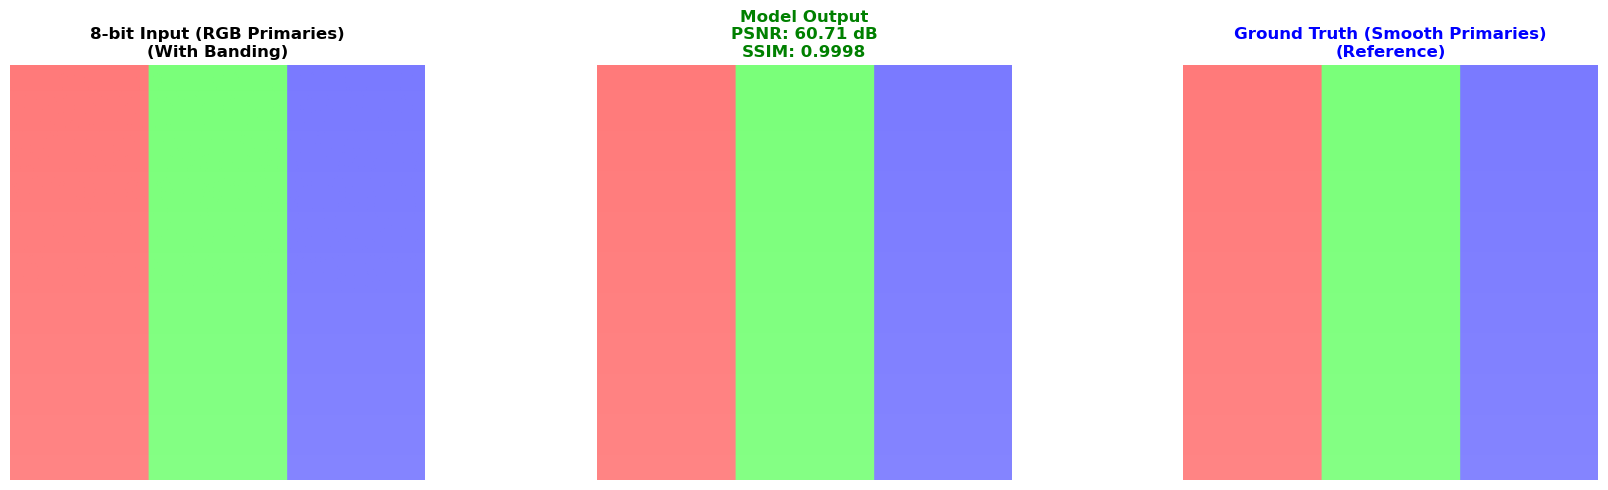

✓ RGB primaries contrast comparison saved to outputs/inference/rgb_primaries_contrast.png

🎯 RGB Primary Analysis:
  → Left column (Red):    Should be smooth gradient with no banding
  → Middle column (Green): Should be smooth gradient with no banding
  → Right column (Blue):  Should be smooth gradient with no banding


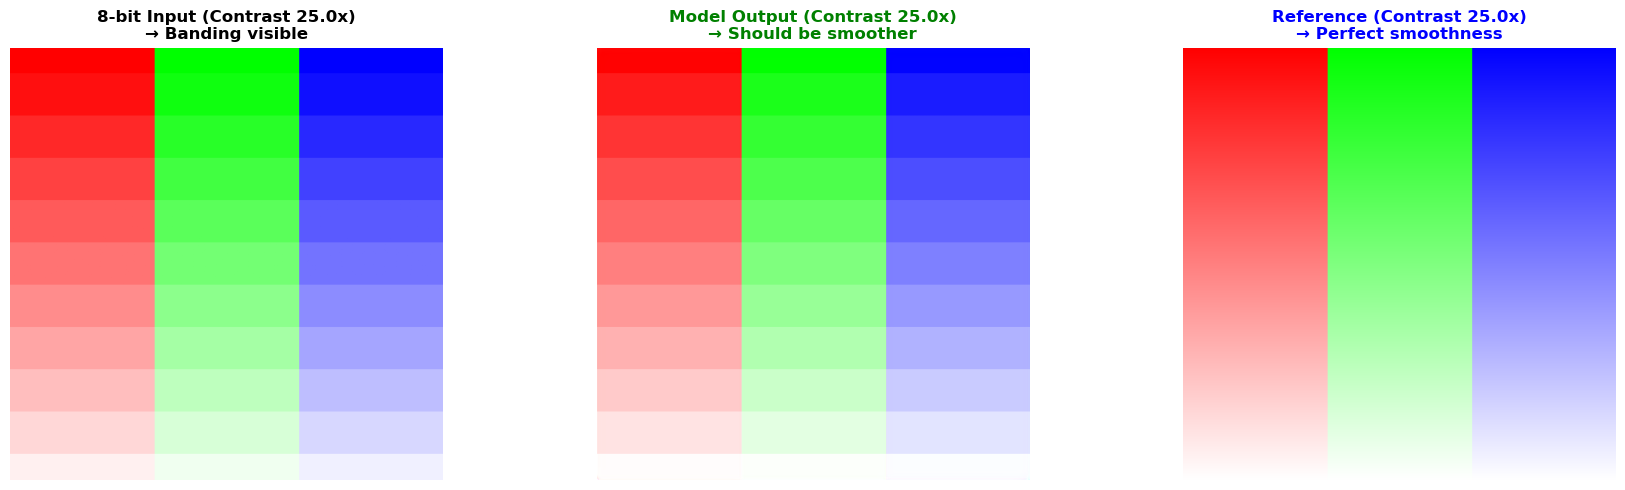

In [10]:
# Convert to display format [H, W, 3]
rgb_8bit_display = np.transpose(np.clip(rgb_8bit_np, 0, 1), (1, 2, 0))
rgb_model_display = np.transpose(np.clip(rgb_model_np, 0, 1), (1, 2, 0))
rgb_hdr_display = np.transpose(np.clip(rgb_hdr_np, 0, 1), (1, 2, 0))

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(rgb_8bit_display)
axes[0].set_title('8-bit Input (RGB Primaries)\n(With Banding)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(rgb_model_display)
axes[1].set_title(f'Model Output\nPSNR: {metrics_rgb["psnr"]:.2f} dB\nSSIM: {metrics_rgb["ssim"]:.4f}', 
                  fontsize=12, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(rgb_hdr_display)
axes[2].set_title('Ground Truth (Smooth Primaries)\n(Reference)', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/rgb_primaries_comparison.png', dpi=150, bbox_inches='tight')
print(f"\n✓ RGB primaries comparison saved to outputs/inference/rgb_primaries_comparison.png")
plt.show()

# High contrast analysis for RGB primaries
contrast_factor = 25.0
rgb_8bit_contrast = (rgb_8bit_display - 0.5) * contrast_factor + 0.5
rgb_model_contrast = (rgb_model_display - 0.5) * contrast_factor + 0.5
rgb_hdr_contrast = (rgb_hdr_display - 0.5) * contrast_factor + 0.5

rgb_8bit_contrast = np.clip(rgb_8bit_contrast, 0, 1)
rgb_model_contrast = np.clip(rgb_model_contrast, 0, 1)
rgb_hdr_contrast = np.clip(rgb_hdr_contrast, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(rgb_8bit_contrast)
axes[0].set_title(f'8-bit Input (Contrast {contrast_factor}x)\n→ Banding visible', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(rgb_model_contrast)
axes[1].set_title(f'Model Output (Contrast {contrast_factor}x)\n→ Should be smoother', fontsize=12, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(rgb_hdr_contrast)
axes[2].set_title(f'Reference (Contrast {contrast_factor}x)\n→ Perfect smoothness', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/rgb_primaries_contrast.png', dpi=150, bbox_inches='tight')
print(f"✓ RGB primaries contrast comparison saved to outputs/inference/rgb_primaries_contrast.png")
print(f"\n🎯 RGB Primary Analysis:")
print(f"  → Left column (Red):    Should be smooth gradient with no banding")
print(f"  → Middle column (Green): Should be smooth gradient with no banding")
print(f"  → Right column (Blue):  Should be smooth gradient with no banding")
plt.show()
